In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

path_to_data = '../data/spotify_data/'

import os
for dirname, _, filenames in os.walk(path_to_data):
    for filename in filenames:
        print(os.path.join(dirname, filename))

../data/spotify_data/dataset.csv


In [2]:
df = pd.read_csv(path_to_data + 'dataset.csv')

In [7]:
display(df.head())
display(df.info())

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           113999 non-null  str    
 3   album_name        113999 non-null  str    
 4   track_name        113999 non-null  str    
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          114000 non-nu

None

Выбросить : track_id, artists, album_name, track_name

In [8]:
df = df.drop(columns=['track_id', 'artists', 'album_name', 'track_name'])

Категориальные признаки : explicit, key, mode, time_signature, track_genre

In [10]:
df.nunique()

Unnamed: 0          114000
popularity             101
duration_ms          50697
explicit                 2
danceability          1174
energy                2083
key                     12
loudness             19480
mode                     2
speechiness           1489
acousticness          5061
instrumentalness      5346
liveness              1722
valence               1790
tempo                45653
time_signature           5
track_genre            114
dtype: int64

track_genre попробую закодировать через средние значения акустических характеристик либо через эмбединг слов

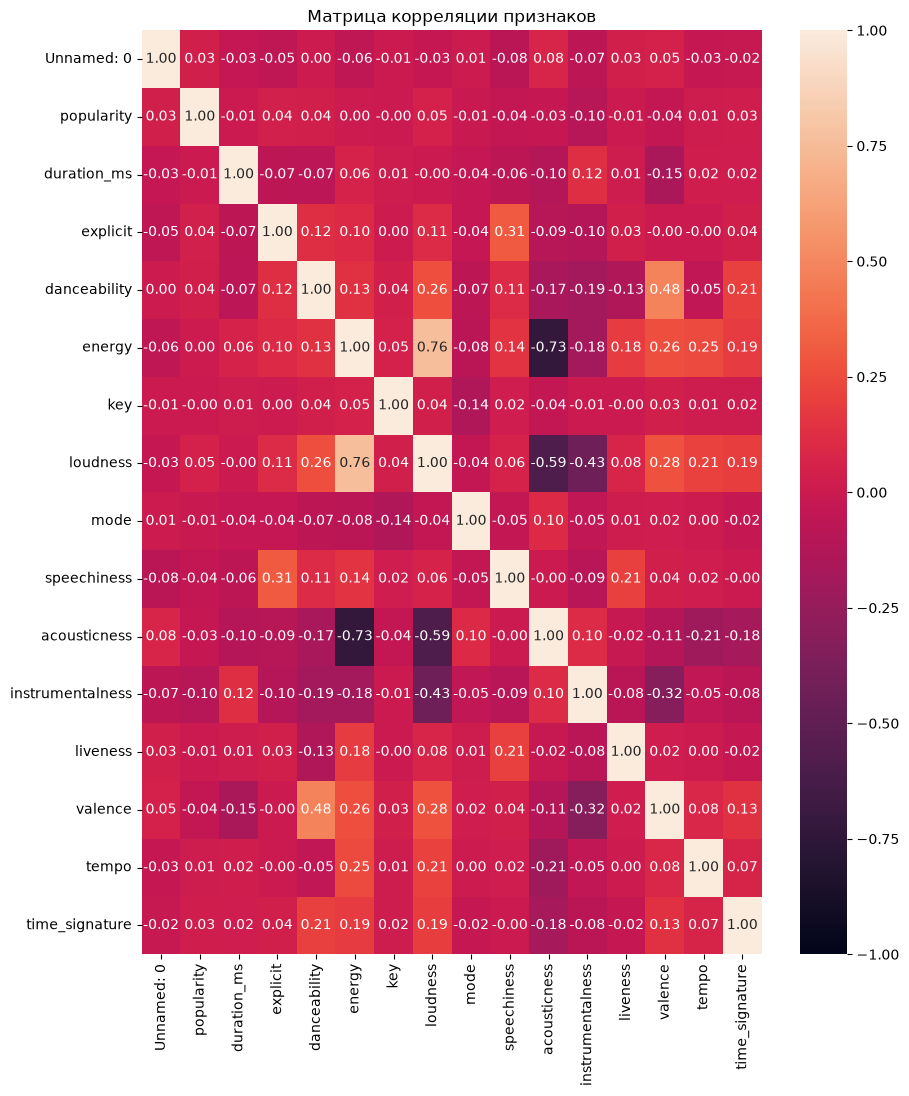

In [16]:
# Матрица корреляций
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(10, 12))
sns.heatmap(corr_matrix, annot=True, vmin=-1, vmax=1, fmt='.2f')
plt.title('Матрица корреляции признаков')
plt.show()

Для начала напишу KNN только на числовых и категориальных признаках, эмбединги слов сделаю позже и сравню полученные результаты.\
Отложить для прогноза: track_id, artists, album_name, track_name \
Отложить для эмбединга: artists  \
Закодировать: explicit, key, mode, time_signature, track_genre 